# Ноутбук 08: Fine-tuning для NER (русский язык)

**Цель:** дообучить модель для распознавания именованных сущностей на русском корпусе.

- Датасет: `wikiann` (`ru`)
- Базовая модель: `cointegrated/rubert-tiny2`
- Классы: `PER`, `ORG`, `LOC`
- Метрика: entity-level `seqeval` (`precision`, `recall`, `f1`)

Что добавлено:
1. Переход с английского датасета на русский.
2. Сравнение качества до и после fine-tuning.
3. Детальная оценка по типам сущностей и примеры ошибок.
4. Тестирование на своих русских предложениях и визуализация.


In [2]:
# Если в новом окружении, раскомментируйте:
# %pip install -q transformers datasets evaluate seqeval accelerate

import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    pipeline as hf_pipeline,
)
import evaluate
from huggingface_hub.utils import disable_progress_bars

disable_progress_bars()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device_name = 'cuda' if torch.cuda.is_available() else 'cpu'
print('torch:', torch.__version__)
print('Устройство:', device_name)


torch: 2.9.1+cu126
Устройство: cuda


## Шаг 1: Загрузка и анализ датасета

In [3]:
dataset_full = load_dataset('wikiann', 'ru')
label_names = dataset_full['train'].features['ner_tags'].feature.names

# Используем подвыборки для быстрого воспроизводимого обучения
train_raw = dataset_full['train'].shuffle(seed=SEED).select(range(1500))
val_raw = dataset_full['validation'].shuffle(seed=SEED).select(range(300))
test_raw = dataset_full['test'].shuffle(seed=SEED).select(range(300))

print('Dataset wikiann/ru загружен')
print('Метки:', label_names)
print('Train:', len(train_raw), 'Val:', len(val_raw), 'Test:', len(test_raw))


Dataset wikiann/ru загружен
Метки: ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC']
Train: 1500 Val: 300 Test: 300


Пример:
Токены: ["'", "''", 'Польша', "''", "'", '—']
Теги:   ['O', 'O', 'B-LOC', 'O', 'O', 'O']


,tag,count,ratio
0,O,6178,0.573684
1,B-PER,506,0.046987
2,I-PER,1059,0.098338
3,B-ORG,601,0.055808
4,I-ORG,1197,0.111152
5,B-LOC,730,0.067787
6,I-LOC,498,0.046244


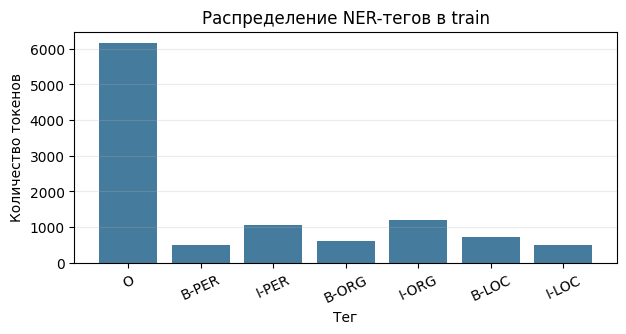

In [4]:
example = train_raw[0]
print('Пример:')
print('Токены:', example['tokens'])
print('Теги:  ', [label_names[t] for t in example['ner_tags']])

all_tags = [tag for ex in train_raw for tag in ex['ner_tags']]
counts = Counter(all_tags)

stats_df = pd.DataFrame(
    [
        {'tag': label_names[tag_id], 'count': count, 'ratio': count / len(all_tags)}
        for tag_id, count in sorted(counts.items())
    ]
)

display(stats_df)

plt.figure(figsize=(7, 3))
plt.bar(stats_df['tag'], stats_df['count'], color='#457b9d')
plt.title('Распределение NER-тегов в train')
plt.xlabel('Тег')
plt.ylabel('Количество токенов')
plt.xticks(rotation=25)
plt.grid(axis='y', alpha=0.25)
plt.show()


## Шаг 2: Токенизация и выравнивание меток

In [5]:
MODEL_NAME = 'cointegrated/rubert-tiny2'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

words = ['Илон', 'Маск', 'посетил', 'Санкт-Петербург']
labels_demo = ['B-PER', 'I-PER', 'O', 'B-LOC']
encoded_demo = tokenizer(words, is_split_into_words=True)

tokens_demo = tokenizer.convert_ids_to_tokens(encoded_demo['input_ids'])
word_ids_demo = encoded_demo.word_ids()

print('Демо субтокенов:')
for token, word_id in zip(tokens_demo, word_ids_demo):
    if word_id is None:
        print(f'{token:16s} -> [спецтокен]')
    else:
        print(f'{token:16s} -> слово="{words[word_id]}" тег={labels_demo[word_id]}')


Демо субтокенов:
[CLS]            -> [спецтокен]
Илон             -> слово="Илон" тег=B-PER
Маск             -> слово="Маск" тег=I-PER
посетил          -> слово="посетил" тег=O
Санкт            -> слово="Санкт-Петербург" тег=B-LOC
-                -> слово="Санкт-Петербург" тег=B-LOC
Петербург        -> слово="Санкт-Петербург" тег=B-LOC
[SEP]            -> [спецтокен]


In [6]:
def tokenize_and_align_labels(examples):
    tokenized = tokenizer(
        examples['tokens'],
        truncation=True,
        max_length=128,
        is_split_into_words=True,
    )

    all_labels = []
    for i, ner_tags in enumerate(examples['ner_tags']):
        word_ids = tokenized.word_ids(batch_index=i)
        previous_word_id = None
        label_ids = []

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != previous_word_id:
                label_ids.append(ner_tags[word_id])
            else:
                label_ids.append(-100)
            previous_word_id = word_id

        all_labels.append(label_ids)

    tokenized['labels'] = all_labels
    return tokenized

train_ds = train_raw.map(tokenize_and_align_labels, batched=True, remove_columns=train_raw.column_names)
val_ds = val_raw.map(tokenize_and_align_labels, batched=True, remove_columns=val_raw.column_names)
test_ds = test_raw.map(tokenize_and_align_labels, batched=True, remove_columns=test_raw.column_names)

print('Токенизация завершена')
print('Поля:', train_ds.column_names)
print('Длина первого примера:', len(train_ds[0]['input_ids']), 'токенов')


Map: 100%|██████████| 300/300 [00:00<00:00, 7025.16 examples/s]

Токенизация завершена
Поля: ['input_ids', 'token_type_ids', 'attention_mask', 'labels']
Длина первого примера: 10 токенов


## Шаг 3: Модель и метрики

In [7]:
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Модель:', MODEL_NAME)
print(f'Всего параметров: {total_params:,} ({total_params/1e6:.1f}M)')
print(f'Обучаемых:        {trainable_params:,} ({trainable_params/1e6:.1f}M)')


Loading weights: 100%|██████████| 53/53 [00:00<00:00, 13258.86it/s]
BertForTokenClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignore

Модель: cointegrated/rubert-tiny2
Всего параметров: 29,098,303 (29.1M)
Обучаемых:        29,098,303 (29.1M)


In [9]:
seqeval = evaluate.load('seqeval')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    true_preds = []
    true_labels = []

    for pred_seq, label_seq in zip(preds, labels):
        curr_preds = []
        curr_labels = []
        for p, l in zip(pred_seq, label_seq):
            if l != -100:
                curr_preds.append(label_names[p])
                curr_labels.append(label_names[l])
        true_preds.append(curr_preds)
        true_labels.append(curr_labels)

    results = seqeval.compute(predictions=true_preds, references=true_labels)
    return {
        'precision': results['overall_precision'],
        'recall': results['overall_recall'],
        'f1': results['overall_f1'],
        'accuracy': results['overall_accuracy'],
    }


## Шаг 4: Fine-tuning

In [10]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir='./results_ner_ru',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=3e-5,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='no',
    logging_strategy='steps',
    logging_steps=50,
    report_to='none',
    disable_tqdm=True,
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('Trainer готов')
print('Эпох:', training_args.num_train_epochs)


Trainer готов
Эпох: 2


In [11]:
baseline = trainer.evaluate()
print('Baseline на validation:')
print(f"  Precision: {baseline['eval_precision']:.3f}")
print(f"  Recall:    {baseline['eval_recall']:.3f}")
print(f"  F1:        {baseline['eval_f1']:.3f}")


{'eval_loss': '2.079', 'eval_model_preparation_time': '0.002', 'eval_precision': '0.02081', 'eval_recall': '0.09067', 'eval_f1': '0.03385', 'eval_accuracy': '0.08238', 'eval_runtime': '0.6187', 'eval_samples_per_second': '484.9', 'eval_steps_per_second': '16.16', 'epoch': 0}
Baseline на validation:
  Precision: 0.021
  Recall:    0.091
  F1:        0.034


In [12]:
train_result = trainer.train()
print('Обучение завершено')
print(f"Время: {train_result.metrics['train_runtime']:.1f} сек")
print(f"Train loss: {train_result.metrics['train_loss']:.3f}")


{'loss': '1.506', 'grad_norm': '3.359', 'learning_rate': '2.218e-05', 'epoch': '0.5319'}
{'eval_loss': '0.9862', 'eval_model_preparation_time': '0.002', 'eval_precision': '0.3563', 'eval_recall': '0.2347', 'eval_f1': '0.283', 'eval_accuracy': '0.6491', 'eval_runtime': '0.18', 'eval_samples_per_second': '1667', 'eval_steps_per_second': '55.57', 'epoch': '1'}
{'loss': '1.071', 'grad_norm': '2.795', 'learning_rate': '1.42e-05', 'epoch': '1.064'}
{'loss': '0.9069', 'grad_norm': '2.426', 'learning_rate': '6.223e-06', 'epoch': '1.596'}
{'eval_loss': '0.8353', 'eval_model_preparation_time': '0.002', 'eval_precision': '0.337', 'eval_recall': '0.3307', 'eval_f1': '0.3338', 'eval_accuracy': '0.7201', 'eval_runtime': '0.172', 'eval_samples_per_second': '1744', 'eval_steps_per_second': '58.14', 'epoch': '2'}
{'train_runtime': '6.314', 'train_samples_per_second': '475.2', 'train_steps_per_second': '29.78', 'train_loss': '1.092', 'epoch': '2'}
Обучение завершено
Время: 6.3 сек
Train loss: 1.092


## Шаг 5: Оценка после обучения

In [13]:
final_test = trainer.evaluate(test_ds)

print('Финальные метрики на test:')
print(f"  Precision: {final_test['eval_precision']:.3f}")
print(f"  Recall:    {final_test['eval_recall']:.3f}")
print(f"  F1:        {final_test['eval_f1']:.3f}")
print(f"  Accuracy:  {final_test['eval_accuracy']:.3f}")
print()
print(f"Сравнение F1: {baseline['eval_f1']:.3f} -> {final_test['eval_f1']:.3f}")


{'eval_loss': '0.8361', 'eval_model_preparation_time': '0.002', 'eval_precision': '0.3483', 'eval_recall': '0.3425', 'eval_f1': '0.3454', 'eval_accuracy': '0.7267', 'eval_runtime': '0.168', 'eval_samples_per_second': '1786', 'eval_steps_per_second': '59.52', 'epoch': '2'}
Финальные метрики на test:
  Precision: 0.348
  Recall:    0.343
  F1:        0.345
  Accuracy:  0.727

Сравнение F1: 0.034 -> 0.345


,entity,precision,recall,f1,support
0,PER,0.641667,0.700000,0.669565,110
1,ORG,0.133333,0.168067,0.148699,119
2,LOC,0.313953,0.203008,0.246575,133


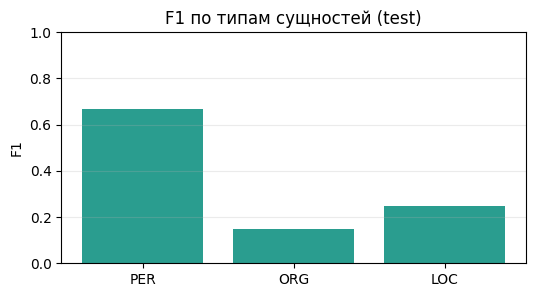

In [14]:
pred_output = trainer.predict(test_ds)
logits = pred_output.predictions
labels = pred_output.label_ids
preds = np.argmax(logits, axis=-1)

true_preds = []
true_labels = []
for pred_seq, label_seq in zip(preds, labels):
    curr_preds = []
    curr_labels = []
    for p, l in zip(pred_seq, label_seq):
        if l != -100:
            curr_preds.append(label_names[p])
            curr_labels.append(label_names[l])
    true_preds.append(curr_preds)
    true_labels.append(curr_labels)

detailed = seqeval.compute(predictions=true_preds, references=true_labels)

rows = []
for entity_type in ['PER', 'ORG', 'LOC']:
    if entity_type in detailed:
        rows.append(
            {
                'entity': entity_type,
                'precision': detailed[entity_type]['precision'],
                'recall': detailed[entity_type]['recall'],
                'f1': detailed[entity_type]['f1'],
                'support': detailed[entity_type]['number'],
            }
        )

entity_df = pd.DataFrame(rows)
display(entity_df)

plt.figure(figsize=(6, 3))
plt.bar(entity_df['entity'], entity_df['f1'], color='#2a9d8f')
plt.ylim(0, 1)
plt.title('F1 по типам сущностей (test)')
plt.ylabel('F1')
plt.grid(axis='y', alpha=0.25)
plt.show()


## Шаг 6: Тест на своих примерах

In [15]:
ner_pipe = hf_pipeline(
    task='token-classification',
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy='first',
    device=0 if torch.cuda.is_available() else -1,
)

custom_texts = [
    'Илон Маск встретился с представителями Сбера в Москве.',
    'Компания Яндекс открыла новый офис в Санкт-Петербурге.',
    'Александр Овечкин подписал контракт с хоккейным клубом в Вашингтоне.',
]

for text in custom_texts:
    preds = ner_pipe(text)
    print('Текст:', text)
    if preds:
        for p in preds:
            print(f"  [{p['word']}] -> {p['entity_group']} ({p['score']:.1%})")
    else:
        print('  Сущности не найдены')
    print()


Текст: Илон Маск встретился с представителями Сбера в Москве.
  [Маск] -> ORG (25.8%)
  [Сбера] -> ORG (24.6%)

Текст: Компания Яндекс открыла новый офис в Санкт-Петербурге.
  Сущности не найдены

Текст: Александр Овечкин подписал контракт с хоккейным клубом в Вашингтоне.
  [Овечкин] -> ORG (21.5%)



In [16]:
from IPython.display import HTML, display

COLORS = {
    'PER': '#cce5ff',
    'ORG': '#d4edda',
    'LOC': '#fff3cd',
}


def render_entities(text):
    preds = ner_pipe(text)
    preds = sorted(preds, key=lambda x: x['start'])

    parts = []
    last = 0
    for p in preds:
        start, end = int(p['start']), int(p['end'])
        parts.append(text[last:start])
        color = COLORS.get(p['entity_group'], '#eeeeee')
        parts.append(
            f"<mark style='background:{color};padding:2px 4px;border-radius:4px;'>"
            f"{text[start:end]}<sup style='font-size:10px;'> {p['entity_group']}</sup></mark>"
        )
        last = end
    parts.append(text[last:])

    html = ''.join(parts)
    display(HTML(html))

sample_text = 'Сергей Брин выступил на конференции в Новосибирске от имени Google.'
print('Визуализация NER для текста:')
print(sample_text)
render_entities(sample_text)


Визуализация NER для текста:
Сергей Брин выступил на конференции в Новосибирске от имени Google.


In [17]:
save_dir = './my_ner_model_ru'
trainer.save_model(save_dir)
tokenizer.save_pretrained(save_dir)

print('Модель сохранена в', save_dir)


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.66it/s]

Модель сохранена в ./my_ner_model_ru
